# 01 — LR vs LR+SGD vs LPM (scikit-learn), with timing

Trains three models on the same synthetic dataset and compares **fit time**, **inference time**,
**peak memory delta**, and **predictive quality**:

1. **Logistic Regression (batch)** — `LogisticRegression(solver="lbfgs")`. Full-batch
   quasi-Newton optimizer: each iteration touches the *entire* training set, so cost scales
   roughly with `n_iterations x n_rows x n_features`.
2. **Logistic Regression + SGD** — `SGDClassifier(loss="log_loss")`. True stochastic gradient
   descent: updates the weights from small batches, so each *epoch* (one pass over the data)
   is cheap, and it typically needs far fewer epochs than `lbfgs` needs iterations to reach a
   *useful* (not exact) solution. Same model family (linear + sigmoid) as #1 — different
   optimizer, so with matched regularization the two should converge to a similar decision
   boundary, not an identical one.
3. **LPM (Linear Probability Model)** — plain `LinearRegression(y ~ X)` on the 0/1 label. Not
   just a different optimizer — a genuinely different model: fits `E[y|X]` as linear rather than
   sigmoid-linear, has a closed-form solution (cheapest to fit), but its predictions aren't
   bounded to `[0, 1]`.

Run `00_generate_synthetic_data.ipynb` first (with the same `N_ROWS`) so the cached arrays exist
under `data/`.

In [1]:
import gc
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------------------------
# CONFIG — every knob for this notebook lives here, each overridable from
# outside via env var (e.g. `N_ROWS=10000000 jupyter nbconvert --execute ...`)
# so you don't have to hand-edit the notebook per run.
# ---------------------------------------------------------------------------
N_ROWS = int(os.environ.get("N_ROWS", 200_000))     # must match a size generated by 00_generate_synthetic_data.ipynb
N_FEATURES = int(os.environ.get("N_FEATURES", 50))
TEST_SIZE = float(os.environ.get("TEST_SIZE", 0.2))
RANDOM_STATE = int(os.environ.get("RANDOM_STATE", 42))
DATA_DIR = Path(os.environ.get("DATA_DIR", "data"))

LR_SOLVER = os.environ.get("LR_SOLVER", "lbfgs")     # LogisticRegression solver
LR_MAX_ITER = int(os.environ.get("LR_MAX_ITER", 200))
LR_C = float(os.environ.get("LR_C", 1.0))            # inverse regularization strength

SGD_MAX_ITER = int(os.environ.get("SGD_MAX_ITER", 1000))   # max epochs, tol decides when to actually stop
SGD_TOL = float(os.environ.get("SGD_TOL", 1e-3))            # early-stopping tolerance
SGD_FAST_MAX_ITER = int(os.environ.get("SGD_FAST_MAX_ITER", 5))  # fixed epoch budget for the "capped" SGD variant

X_PATH = DATA_DIR / f"X_{N_ROWS}.npy"
Y_PATH = DATA_DIR / f"y_{N_ROWS}.npy"

if not (X_PATH.exists() and Y_PATH.exists()):
    raise FileNotFoundError(
        f"{X_PATH} / {Y_PATH} not found. Run 00_generate_synthetic_data.ipynb with "
        f"N_ROWS={N_ROWS} first."
    )

process = psutil.Process(os.getpid())
print(f"RSS before load: {process.memory_info().rss / 1e9:.2f} GB")

X = np.load(X_PATH)   # full load into RAM (not memmap) — mirrors real training memory usage
y = np.load(Y_PATH)

print(f"RSS after load:  {process.memory_info().rss / 1e9:.2f} GB")
print(f"X: {X.shape} {X.dtype}, y: {y.shape} {y.dtype}")

RSS before load: 0.19 GB
RSS after load:  0.23 GB
X: (200000, 50) float32, y: (200000,) float32


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
del X, y
gc.collect()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"RSS after split: {process.memory_info().rss / 1e9:.2f} GB")

Train: (160000, 50), Test: (40000, 50)
RSS after split: 0.29 GB


In [3]:
def measure(fn, *args, **kwargs):
    """Run fn, returning (result, wall_seconds, rss_delta_gb)."""
    gc.collect()
    rss_before = process.memory_info().rss
    t0 = time.perf_counter()
    result = fn(*args, **kwargs)
    elapsed = time.perf_counter() - t0
    rss_after = process.memory_info().rss
    return result, elapsed, (rss_after - rss_before) / 1e9


results = []  # collect dict rows for the comparison table

## Model 1 — Logistic Regression (full-batch, `lbfgs`)

In [4]:
lr_model = LogisticRegression(solver=LR_SOLVER, max_iter=LR_MAX_ITER, C=LR_C)
_, lr_fit_time, lr_fit_mem = measure(lr_model.fit, X_train, y_train)

(lr_proba, lr_pred), lr_predict_time, lr_predict_mem = measure(
    lambda: (lr_model.predict_proba(X_test)[:, 1], lr_model.predict(X_test))
)

results.append({
    "model": "LogisticRegression (lbfgs)",
    "fit_time_s": lr_fit_time,
    "predict_time_s": lr_predict_time,
    "fit_rss_delta_gb": lr_fit_mem,
    "n_iter": int(lr_model.n_iter_[0]),
    "accuracy": accuracy_score(y_test, lr_pred),
    "auc": roc_auc_score(y_test, lr_proba),
    "log_loss": log_loss(y_test, lr_proba),
})
print(f"fit: {lr_fit_time:.2f}s ({lr_model.n_iter_[0]} iterations), predict: {lr_predict_time:.3f}s")

fit: 0.09s (6 iterations), predict: 0.006s


## Model 2 — Logistic Regression + SGD

`SGDClassifier`'s default L2 penalty (`alpha=0.0001`) is not the same regularization strength as
`LogisticRegression`'s default (`C=1.0`). To make "is the model the same?" a fair question, match
them: `alpha ~= 1 / (C * n_train)`.

In [5]:
alpha_matched = 1.0 / (LR_C * X_train.shape[0])

sgd_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=alpha_matched,
    max_iter=SGD_MAX_ITER,
    tol=SGD_TOL,
    random_state=RANDOM_STATE,
)
_, sgd_fit_time, sgd_fit_mem = measure(sgd_model.fit, X_train, y_train)

(sgd_proba, sgd_pred), sgd_predict_time, sgd_predict_mem = measure(
    lambda: (sgd_model.predict_proba(X_test)[:, 1], sgd_model.predict(X_test))
)

results.append({
    "model": "SGDClassifier (log_loss)",
    "fit_time_s": sgd_fit_time,
    "predict_time_s": sgd_predict_time,
    "fit_rss_delta_gb": sgd_fit_mem,
    "n_iter": int(sgd_model.n_iter_),
    "accuracy": accuracy_score(y_test, sgd_pred),
    "auc": roc_auc_score(y_test, sgd_proba),
    "log_loss": log_loss(y_test, sgd_proba),
})
ratio = lr_fit_time / sgd_fit_time
print(f"fit: {sgd_fit_time:.2f}s ({sgd_model.n_iter_} epochs), predict: {sgd_predict_time:.3f}s")
print(f"SGD fit time vs full-batch LR fit time: {ratio:.2f}x "
      f"({'faster' if ratio > 1 else 'slower'} than lbfgs at this N and tol)")

fit: 2.66s (58 epochs), predict: 0.002s
SGD fit time vs full-batch LR fit time: 0.03x (slower than lbfgs at this N and tol)


### SGD with a fixed epoch budget (the "fast, approximate" mode)

The run above let `tol` decide when to stop — on well-conditioned, moderate-size data that can
mean SGD needs *more* epochs (and more wall time) than full-batch `lbfgs` needs full-batch
iterations, since quasi-Newton methods like `lbfgs` converge in very few passes once the problem
is well-conditioned. **SGD's real speed advantage comes from deliberately capping the epoch
count** in exchange for a hard time budget — that's the pattern to reach for at 10-20M rows if
wall-clock time, not convergence, is the constraint. How much quality you give up for that time
budget is not automatic, though: too few epochs (see the result below) can cost *far* more than
"a bit" of accuracy — `SGD_FAST_MAX_ITER` is a dial you need to tune against your own time budget
and data, not a fixed good default.

In [6]:
sgd_fast_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=alpha_matched,
    max_iter=SGD_FAST_MAX_ITER,
    tol=None,  # ignore convergence criteria, always run exactly SGD_FAST_MAX_ITER epochs
    random_state=RANDOM_STATE,
)
_, sgd_fast_fit_time, sgd_fast_fit_mem = measure(sgd_fast_model.fit, X_train, y_train)

(sgd_fast_proba, sgd_fast_pred), sgd_fast_predict_time, _ = measure(
    lambda: (sgd_fast_model.predict_proba(X_test)[:, 1], sgd_fast_model.predict(X_test))
)

results.append({
    "model": f"SGDClassifier (log_loss, capped @ {SGD_FAST_MAX_ITER} epochs)",
    "fit_time_s": sgd_fast_fit_time,
    "predict_time_s": sgd_fast_predict_time,
    "fit_rss_delta_gb": sgd_fast_fit_mem,
    "n_iter": SGD_FAST_MAX_ITER,
    "accuracy": accuracy_score(y_test, sgd_fast_pred),
    "auc": roc_auc_score(y_test, sgd_fast_proba),
    "log_loss": log_loss(y_test, sgd_fast_proba),
})
ratio = lr_fit_time / sgd_fast_fit_time
print(f"fit: {sgd_fast_fit_time:.3f}s ({SGD_FAST_MAX_ITER} epochs, fixed)")
print(f"capped-SGD fit time vs full-batch LR fit time: {ratio:.2f}x "
      f"({'faster' if ratio > 1 else 'slower'} than lbfgs at this N)")

fit: 0.227s (5 epochs, fixed)
capped-SGD fit time vs full-batch LR fit time: 0.40x (slower than lbfgs at this N)


## Model 3 — LPM (Linear Probability Model)

Plain OLS on the 0/1 label. Predictions are unbounded, so `log_loss` needs clipping into
`(0, 1)` first, and AUC is computed from the raw (unclipped) score since AUC only needs a
ranking, not a probability.

In [7]:
lpm_model = LinearRegression()
_, lpm_fit_time, lpm_fit_mem = measure(lpm_model.fit, X_train, y_train)

lpm_raw_pred, lpm_predict_time, lpm_predict_mem = measure(lpm_model.predict, X_test)
lpm_pred_clipped = np.clip(lpm_raw_pred, 1e-6, 1 - 1e-6)
lpm_class_pred = (lpm_raw_pred >= 0.5).astype(int)

out_of_bounds_frac = ((lpm_raw_pred < 0) | (lpm_raw_pred > 1)).mean()

results.append({
    "model": "LinearRegression / LPM",
    "fit_time_s": lpm_fit_time,
    "predict_time_s": lpm_predict_time,
    "fit_rss_delta_gb": lpm_fit_mem,
    "n_iter": None,
    "accuracy": accuracy_score(y_test, lpm_class_pred),
    "auc": roc_auc_score(y_test, lpm_raw_pred),
    "log_loss": log_loss(y_test, lpm_pred_clipped),
})
ratio = lr_fit_time / lpm_fit_time
print(f"fit: {lpm_fit_time:.3f}s, predict: {lpm_predict_time:.3f}s")
print(f"fraction of test predictions outside [0,1]: {out_of_bounds_frac:.1%}")
print(f"LPM fit time vs full-batch LR fit time: {ratio:.2f}x "
      f"({'faster' if ratio > 1 else 'slower'} than lbfgs at this N — LPM is closed-form, no iteration)")

fit: 0.109s, predict: 0.001s
fraction of test predictions outside [0,1]: 11.9%
LPM fit time vs full-batch LR fit time: 0.84x (slower than lbfgs at this N — LPM is closed-form, no iteration)


## Comparison table

In [8]:
results_df = pd.DataFrame(results).set_index("model")
results_df

,fit_time_s,predict_time_s,fit_rss_delta_gb,n_iter,accuracy,auc,log_loss
model,,,,,,,
LogisticRegression (lbfgs),0.091629,0.006281,0.064750,6.0,0.801150,0.886883,0.419744
SGDClassifier (log_loss),2.659048,0.002160,-0.063930,58.0,0.789975,0.875663,0.441980
"SGDClassifier (log_loss, capped @ 5 epochs)",0.226595,0.002157,0.000000,5.0,0.717125,0.792256,1.428642
LinearRegression / LPM,0.109443,0.000856,0.032244,NaN,0.801075,0.886898,0.443591


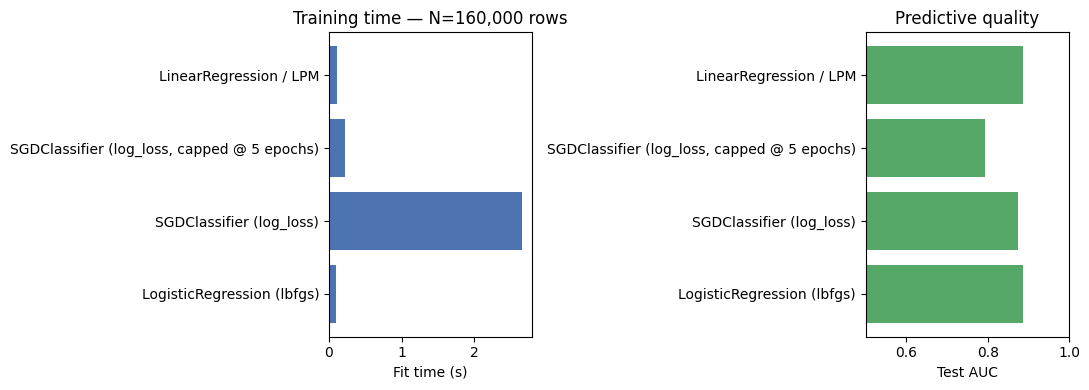

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].barh(results_df.index, results_df["fit_time_s"], color="#4C72B0")
axes[0].set_xlabel("Fit time (s)")
axes[0].set_title(f"Training time — N={X_train.shape[0]:,} rows")

axes[1].barh(results_df.index, results_df["auc"], color="#55A868")
axes[1].set_xlim(0.5, 1.0)
axes[1].set_xlabel("Test AUC")
axes[1].set_title("Predictive quality")

fig.tight_layout()
plt.show()

## Coefficient comparison — LR vs LPM

For a logistic model, the *marginal effect* of `x_j` on `P(y=1)` at a given point is
`beta_j * p * (1 - p)`, not `beta_j` directly. Scaling LR's coefficients by the average
`p_hat * (1 - p_hat)` on the training set puts them on roughly the same footing as LPM's
coefficients (which *are* directly marginal effects, by construction) — this is the standard way
econometricians sanity-check LPM against a logit/probit.

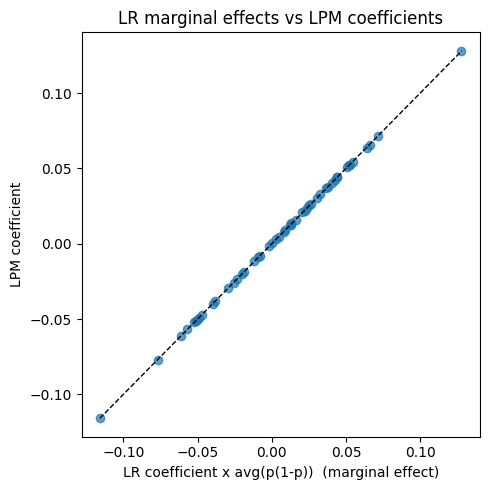

correlation: 1.0000


In [10]:
train_proba = lr_model.predict_proba(X_train)[:, 1]
avg_derivative = np.mean(train_proba * (1 - train_proba))
lr_marginal_effects = lr_model.coef_[0] * avg_derivative

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(lr_marginal_effects, lpm_model.coef_, alpha=0.7)
lims = [min(lr_marginal_effects.min(), lpm_model.coef_.min()),
        max(lr_marginal_effects.max(), lpm_model.coef_.max())]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("LR coefficient x avg(p(1-p))  (marginal effect)")
ax.set_ylabel("LPM coefficient")
ax.set_title("LR marginal effects vs LPM coefficients")
fig.tight_layout()
plt.show()

corr = np.corrcoef(lr_marginal_effects, lpm_model.coef_)[0, 1]
print(f"correlation: {corr:.4f}")

## Takeaways

- **Is SGD fast? — it depends on what "SGD" is stopping on.** Run to its own `tol`-based
  convergence, `SGDClassifier` can end up needing *more* epochs (and more wall time) than
  full-batch `lbfgs` needs iterations, because `lbfgs` is a quasi-Newton method and converges in
  very few full-data passes once the problem is well-conditioned (that's what you likely saw
  above: `n_iter` for `lbfgs` is small, while tol-converged SGD's epoch count is much larger).
  SGD's real speed advantage isn't "SGD is inherently faster" — it's that you can **cap the
  epoch count** and stop on a wall-clock/epoch budget instead of a convergence criterion (the
  "capped SGD" row above). How much accuracy that costs is *not* automatic — the 5-epoch default
  above undershot noticeably (worse log-loss/accuracy than either lbfgs or tol-converged SGD), so
  treat `SGD_FAST_MAX_ITER` as a dial to sweep against your own time budget, not a safe default.
  At 10-20M rows the capped approach is usually still worth reaching for, because a single
  `lbfgs` iteration itself becomes expensive (each one is a full pass over all 10-20M rows) and
  `SGDClassifier` also supports `partial_fit` for streaming data that doesn't fit in RAM at all,
  which `lbfgs` cannot do — but validate the epoch/quality trade-off at your actual scale rather
  than assuming this small-N smoke-test result generalizes.
- **Is the model the same?** Same *functional form* (linear score through a sigmoid) as `lbfgs`
  logistic regression, different *fitted parameters* — SGD (tol-converged or capped) is an
  approximate/stochastic optimizer, so even with matched regularization the coefficients land
  close to, not exactly on, the `lbfgs` solution. Check AUC/log-loss above to see how much (if
  any) quality was traded away, especially for the capped variant.
- **LPM** is the cheapest to fit (closed-form OLS, no iterative optimization at all — its fit
  time is roughly independent of how "easy" or "hard" the classification boundary is, unlike the
  two iterative methods) and its coefficients are directly interpretable as marginal probability
  effects — but it can and will produce probabilities outside `[0, 1]` (see the
  `out_of_bounds_frac` printed above), and it's a genuinely different model, not a faster way to
  fit the same one.